In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("archive/data-final.csv", sep="\t")

df.shape


(1015341, 110)

In [3]:

df.head()


,EXT1,EXT2,EXT3,EXT4,EXT5,EXT6,EXT7,EXT8,EXT9,EXT10,...,dateload,screenw,screenh,introelapse,testelapse,endelapse,IPC,country,lat_appx_lots_of_err,long_appx_lots_of_err
0,4.0,1.0,5.0,2.0,5.0,1.0,5.0,2.0,4.0,1.0,...,2016-03-03 02:01:01,768.0,1024.0,9.0,234.0,6,1,GB,51.5448,0.1991
1,3.0,5.0,3.0,4.0,3.0,3.0,2.0,5.0,1.0,5.0,...,2016-03-03 02:01:20,1360.0,768.0,12.0,179.0,11,1,MY,3.1698,101.706
2,2.0,3.0,4.0,4.0,3.0,2.0,1.0,3.0,2.0,5.0,...,2016-03-03 02:01:56,1366.0,768.0,3.0,186.0,7,1,GB,54.9119,-1.3833
3,2.0,2.0,2.0,3.0,4.0,2.0,2.0,4.0,1.0,4.0,...,2016-03-03 02:02:02,1920.0,1200.0,186.0,219.0,7,1,GB,51.75,-1.25
4,3.0,3.0,3.0,3.0,5.0,3.0,3.0,5.0,3.0,4.0,...,2016-03-03 02:02:57,1366.0,768.0,8.0,315.0,17,2,KE,1.0,38.0


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1015341 entries, 0 to 1015340
Columns: 110 entries, EXT1 to long_appx_lots_of_err
dtypes: float64(104), int64(2), object(4)
memory usage: 852.1+ MB


In [5]:
#df.columns.tolist()

In [6]:
df = df[df["IPC"] == 1]
df.shape

(696845, 110)

In [7]:
cols_noE = [
    col for col in df.columns
    if col.startswith(("EXT", "EST", "AGR", "CSN", "OPN"))
    and not col.endswith("_E")
]

df_noE = df[cols_noE]


In [8]:
df_noE.isnull().sum().sort_values(ascending=False).head()


EXT1     1141
CSN8     1141
AGR8     1141
AGR9     1141
AGR10    1141
dtype: int64

In [9]:
empty_rows = df_noE.isnull().all(axis=1)

empty_rows.sum()



1141

In [10]:
df_noE = df_noE.dropna(how="all")
empty_rows = df_noE.isnull().all(axis=1)

empty_rows.sum()


0

In [11]:
df_noE.isnull().sum().sort_values(ascending=False).head()


EXT1     0
CSN8     0
AGR8     0
AGR9     0
AGR10    0
dtype: int64

In [12]:
cols_withE = [
    col for col in df.columns
    if col.startswith(("EXT", "EST", "AGR", "CSN", "OPN"))
]

df_withE = df[cols_withE]

# zadrži ISTE REDOVE kao u df_noE
df_withE = df_withE.loc[df_noE.index]

In [14]:
df_withE.isnull().sum().sort_values(ascending=False).head()

EXT1      0
EST4_E    0
AGR4_E    0
AGR3_E    0
AGR2_E    0
dtype: int64

In [15]:
df_noE.shape

(695704, 50)

In [16]:
df_withE.shape

(695704, 100)

In [17]:
from sklearn.preprocessing import StandardScaler

scaler_noE = StandardScaler()
X_noE_scaled = scaler_noE.fit_transform(df_noE)

scaler_withE = StandardScaler()
X_withE_scaled = scaler_withE.fit_transform(df_withE)


In [18]:
from sklearn.decomposition import PCA

pca_noE = PCA(n_components=2)
df_pca_noE = pd.DataFrame(
    pca_noE.fit_transform(X_noE_scaled),
    columns=["PC1", "PC2"],
    index=df_noE.index
)

pca_withE = PCA(n_components=2)
df_pca_withE = pd.DataFrame(
    pca_withE.fit_transform(X_withE_scaled),
    columns=["PC1", "PC2"],
    index=df_noE.index
)


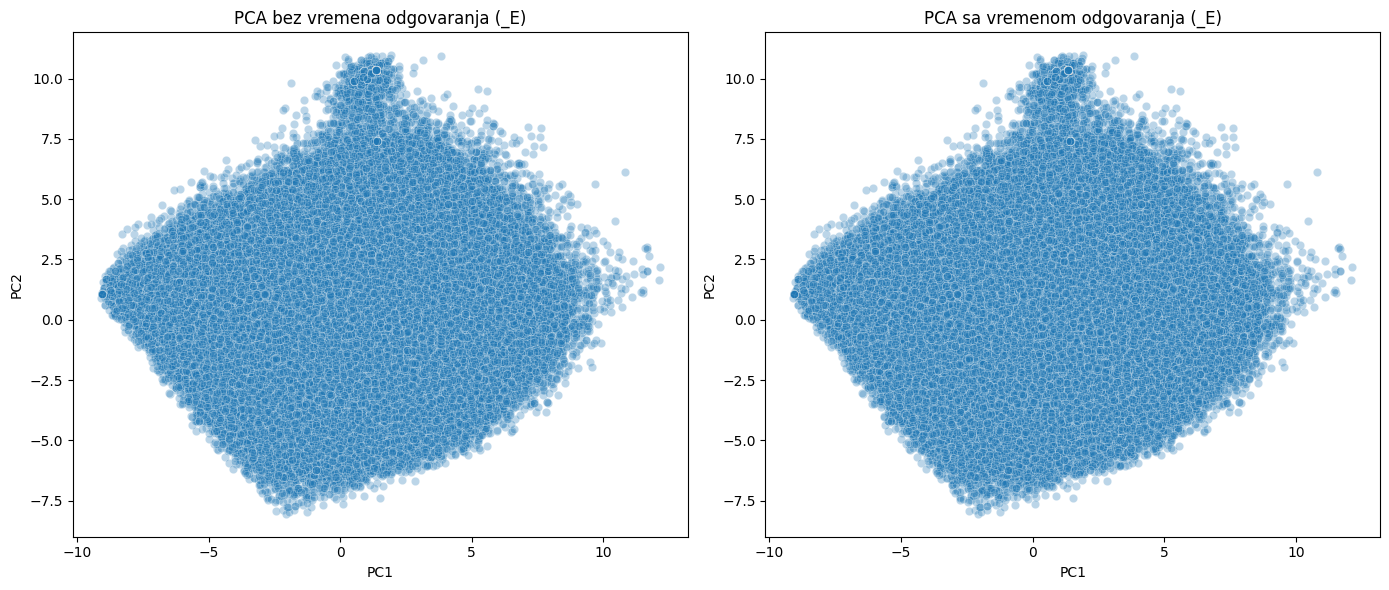

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14,6))

sns.scatterplot(
    x="PC1", y="PC2",
    data=df_pca_noE,
    alpha=0.3,
    ax=axes[0]
)
axes[0].set_title("PCA bez vremena odgovaranja (_E)")

sns.scatterplot(
    x="PC1", y="PC2",
    data=df_pca_withE,
    alpha=0.3,
    ax=axes[1]
)
axes[1].set_title("PCA sa vremenom odgovaranja (_E)")

plt.tight_layout()
plt.show()
